# 我使用了什么库？

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import random
import numpy as np
from PIL import Image

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision.transforms.v2 import Compose, Normalize

from data_generation.image_classification import generate_dataset
from helpers import index_splitter, make_balanced_sampler

from StepClass.v1 import StepByStep
from plots.chapter5 import *

# 然后，我要干什么？

在ch04，处理了图像的二分类问题:

对于图像，我们将其展平成了一维数组，像素作为特征，在此期间会丢失信息。

而对于隐藏层中的权重，则可以可视化为图像，即是**滤波器**的雏形

---

在这里，要继续处理图像的多分类问题:

新的激活函数,新的损失函数，新的层类型，

以及作为其基础的卷积+池化+展平，还有滤波器和特征的可视化

---

首先，要了解训练前对图像的特殊处理: 卷积+池化+展平，让张量在展平的过程中没有信息损失

# 卷积

**Q**: 卷积是什么？有什么用处？

**Q**: 卷积核和滤波器是什么？

**Q**: 滤波器的输入，操作和输出是什么？

**Q**: 感受野是什么？

**Q**: 步幅是什么？对图像的影响是什么？如何计算影响？

**Q**: 滤波器对图像的影响是什么？如何计算影响？

结合代码：

**Q**: 卷积有哪些使用方式？

**Q**: 如何特定一个滤波器？有什么注意事项和应用场景？


In [2]:
# 模拟卷积的计算

single = np.array(
    [[[[5, 0, 8, 7, 8, 1],
       [1, 9, 5, 0, 7, 7],
       [6, 0, 2, 4, 6, 6],
       [9, 7, 6, 6, 8, 4],
       [8, 3, 8, 5, 1, 3],
       [7, 2, 7, 0, 1, 0]]]]
)

# NCHW格式
print(single.shape) 

identity = np.array(
    [[[[0, 0, 0],
       [0, 1, 0],
       [0, 0, 0]]]]
)

# NCHW格式
print(identity.shape)


# 手动卷积计算
region = single[:, :, 0:3, 0:3]
filtered_region = region * identity
total = filtered_region.sum()
print(total)


# 手动移动步幅
new_region = single[:, :, 0:3, (0+1):(3+1)]
new_filtered_region = new_region * identity
new_total = new_filtered_region.sum()
print(new_total)


(1, 1, 6, 6)
(1, 1, 3, 3)
9
5


In [3]:
# 程序5-1: pytorch的卷积使用

image = torch.as_tensor(single).float()

# 方法1: 函数式

## 定义卷积核
kernel_identity = torch.as_tensor(identity).float()
convolved = F.conv2d(image, kernel_identity, stride=1)
print(convolved)

# 方法2: 模板式

## 注意卷积核的随机初始化
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1)
print(conv(image))

tensor([[[[9., 5., 0., 7.],
          [0., 2., 4., 6.],
          [7., 6., 6., 8.],
          [3., 8., 5., 1.]]]])
tensor([[[[-4.8943, -2.0504, -6.9764, -6.8100],
          [-5.9420, -5.9276, -6.2342, -6.1251],
          [-2.8935, -2.4241, -4.6901, -4.1912],
          [-6.9390, -4.3480, -3.6529, -2.9418]]]],
       grad_fn=<ConvolutionBackward0>)


In [4]:
# 程序5-2: 卷积的通道个数

conv_multiple = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1)
print(conv_multiple.weight)
print(conv_multiple(image))

Parameter containing:
tensor([[[[-0.1522,  0.0044, -0.1232],
          [-0.2708,  0.0922, -0.0225],
          [ 0.2720, -0.2895, -0.2795]]],


        [[[ 0.1978,  0.0418, -0.2568],
          [ 0.1091,  0.0513, -0.2611],
          [-0.0401,  0.2219, -0.1507]]]], requires_grad=True)
tensor([[[[-0.0866, -4.3605, -5.8350, -2.8515],
          [-3.5144, -2.6238, -4.1322, -3.1587],
          [-3.8748, -4.7190, -1.6885, -1.9266],
          [-4.6394, -3.3080, -1.8357, -2.8498]],

         [[-2.5078, -0.5487, -1.7237,  0.0946],
          [-0.4542,  1.0282, -2.2319, -1.5608],
          [-0.5787, -0.7026, -1.6319, -1.0744],
          [-1.5874,  0.8343, -0.3452,  0.3640]]]],
       grad_fn=<ConvolutionBackward0>)


In [5]:
# 程序5-3: 指定卷积核

with torch.no_grad():
    conv.weight[0] = kernel_identity
    conv.bias[0] = 0

print(conv(image))

tensor([[[[9., 5., 0., 7.],
          [0., 2., 4., 6.],
          [7., 6., 6., 8.],
          [3., 8., 5., 1.]]]], grad_fn=<ConvolutionBackward0>)


In [6]:
# 程序5-4: 指定卷积核步幅

convolved_stride2 = F.conv2d(image, kernel_identity, stride=2)
print(convolved_stride2)

tensor([[[[9., 0.],
          [7., 6.]]]])


# 填充

**Q**: 填充的作用？

**Q**: 填充对图像的影响？如何计算影响？

**Q**: 填充有几种模式？各自的填充逻辑是什么？

结合代码:

**Q**: pytorch的填充有几种实现方式？

In [7]:
#程序5-5: 填充的使用方式

# 方法1: 模板式
constant_padder = nn.ConstantPad2d(padding=1,value=0)
print(constant_padder(image))

# 方法2: 函数式

## pad可以指定不对成填充
padded = F.pad(image, pad=(1,1,1,1),mode='constant',value=0)
print(padded)

tensor([[[[0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 5., 0., 8., 7., 8., 1., 0.],
          [0., 1., 9., 5., 0., 7., 7., 0.],
          [0., 6., 0., 2., 4., 6., 6., 0.],
          [0., 9., 7., 6., 6., 8., 4., 0.],
          [0., 8., 3., 8., 5., 1., 3., 0.],
          [0., 7., 2., 7., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.]]]])
tensor([[[[0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 5., 0., 8., 7., 8., 1., 0.],
          [0., 1., 9., 5., 0., 7., 7., 0.],
          [0., 6., 0., 2., 4., 6., 6., 0.],
          [0., 9., 7., 6., 6., 8., 4., 0.],
          [0., 8., 3., 8., 5., 1., 3., 0.],
          [0., 7., 2., 7., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.]]]])


In [8]:
#程序5-6: replicate填充模式

replicate_padder = nn.ReplicationPad2d(padding=1)
print(replicate_padder(image))

padded = F.pad(image, pad=(1,1,1,1),mode='replicate')
print(padded)


tensor([[[[5., 5., 0., 8., 7., 8., 1., 1.],
          [5., 5., 0., 8., 7., 8., 1., 1.],
          [1., 1., 9., 5., 0., 7., 7., 7.],
          [6., 6., 0., 2., 4., 6., 6., 6.],
          [9., 9., 7., 6., 6., 8., 4., 4.],
          [8., 8., 3., 8., 5., 1., 3., 3.],
          [7., 7., 2., 7., 0., 1., 0., 0.],
          [7., 7., 2., 7., 0., 1., 0., 0.]]]])
tensor([[[[5., 5., 0., 8., 7., 8., 1., 1.],
          [5., 5., 0., 8., 7., 8., 1., 1.],
          [1., 1., 9., 5., 0., 7., 7., 7.],
          [6., 6., 0., 2., 4., 6., 6., 6.],
          [9., 9., 7., 6., 6., 8., 4., 4.],
          [8., 8., 3., 8., 5., 1., 3., 3.],
          [7., 7., 2., 7., 0., 1., 0., 0.],
          [7., 7., 2., 7., 0., 1., 0., 0.]]]])


In [9]:
#程序5-7: reflect填充模式

reflect_padder = nn.ReflectionPad2d(padding=1)
print(reflect_padder(image))

padded = F.pad(image, pad=(1,1,1,1),mode='reflect')
print(padded)

tensor([[[[9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 5., 0., 8., 7., 8., 1., 8.],
          [9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 6., 0., 2., 4., 6., 6., 6.],
          [7., 9., 7., 6., 6., 8., 4., 8.],
          [3., 8., 3., 8., 5., 1., 3., 1.],
          [2., 7., 2., 7., 0., 1., 0., 1.],
          [3., 8., 3., 8., 5., 1., 3., 1.]]]])
tensor([[[[9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 5., 0., 8., 7., 8., 1., 8.],
          [9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 6., 0., 2., 4., 6., 6., 6.],
          [7., 9., 7., 6., 6., 8., 4., 8.],
          [3., 8., 3., 8., 5., 1., 3., 1.],
          [2., 7., 2., 7., 0., 1., 0., 1.],
          [3., 8., 3., 8., 5., 1., 3., 1.]]]])


In [10]:
#程序5-8: circular填充模式

padded = F.pad(image, pad=(1,1,1,1),mode='circular')
print(padded)

tensor([[[[0., 7., 2., 7., 0., 1., 0., 7.],
          [1., 5., 0., 8., 7., 8., 1., 5.],
          [7., 1., 9., 5., 0., 7., 7., 1.],
          [6., 6., 0., 2., 4., 6., 6., 6.],
          [4., 9., 7., 6., 6., 8., 4., 9.],
          [3., 8., 3., 8., 5., 1., 3., 8.],
          [0., 7., 2., 7., 0., 1., 0., 7.],
          [1., 5., 0., 8., 7., 8., 1., 5.]]]])


## 其他滤波器

In [11]:
# 展示边缘检测滤波器

edge = np.array(
    [[[[0, 1, 0],
       [1, -4, 1],
       [0, 1, 0]]]]
)
kernel_edge = torch.as_tensor(edge).float()
print(kernel_edge.shape)



torch.Size([1, 1, 3, 3])


In [12]:
# 边缘检测滤波器的使用
padded = F.pad(image, (1, 1, 1, 1), mode='constant', value=0)
conv_padded = F.conv2d(padded, kernel_edge, stride=1)

print(conv_padded)

tensor([[[[-19.,  22., -20., -12., -17.,  11.],
          [ 16., -30.,  -1.,  23.,  -7., -14.],
          [-14.,  24.,   7.,  -2.,   1.,  -7.],
          [-15., -10.,  -1.,  -1., -15.,   1.],
          [-13.,  13., -11.,  -5.,  13.,  -7.],
          [-18.,   9., -18.,  13.,  -3.,   4.]]]])


# 池化

**Q**: 池化的处理逻辑是什么？

**Q**: 池化核大小对图像的影响？如何影响？

**Q**: 有哪些类型的池化操作？

**Q**: 步幅对池化的影响？

**Q**: 卷积填充池化有那些维度版本？

结合代码:

**Q** 池化有几种实现形式？

In [13]:
#程序5-9: 最大池化

pooled = F.max_pool2d(conv_padded,kernel_size=2)
print(pooled)

pooled2 = nn.MaxPool2d(kernel_size=2)(conv_padded)
print(pooled)

tensor([[[[22., 23., 11.],
          [24.,  7.,  1.],
          [13., 13., 13.]]]])
tensor([[[[22., 23., 11.],
          [24.,  7.,  1.],
          [13., 13., 13.]]]])


In [14]:
#程序5-10: 平均池化

pooled = F.avg_pool2d(conv_padded,kernel_size=2)
print(pooled)

pooled2 = nn.AvgPool2d(kernel_size=2)(conv_padded)
print(pooled)

tensor([[[[-2.7500, -2.5000, -6.7500],
          [-3.7500,  0.7500, -5.0000],
          [-2.2500, -5.2500,  1.7500]]]])
tensor([[[[-2.7500, -2.5000, -6.7500],
          [-3.7500,  0.7500, -5.0000],
          [-2.2500, -5.2500,  1.7500]]]])


In [15]:
#程序5-11: 池化的步幅
print(F.max_pool2d(conv_padded, kernel_size=3, stride=1))

tensor([[[[24., 24., 23., 23.],
          [24., 24., 23., 23.],
          [24., 24., 13., 13.],
          [13., 13., 13., 13.]]]])


# 展平

结合代码：

**Q**: 展平的模块版和函数版本如何实现？

In [16]:
#程序5-12: 展平

# 模块版
flattened = nn.Flatten()(pooled)
print(flattened)

# 函数版
print(pooled.view(1,-1))

tensor([[-2.7500, -2.5000, -6.7500, -3.7500,  0.7500, -5.0000, -2.2500, -5.2500,
          1.7500]])
tensor([[-2.7500, -2.5000, -6.7500, -3.7500,  0.7500, -5.0000, -2.2500, -5.2500,
          1.7500]])


# 典型架构

**Q**: 典型架构的组成？

**Q**: 卷积块的组成？

**Q**: 卷积块的职责是什么？分类又由谁实现？

**Q**: LeNet-5是什么？

结合代码：

**Q**：描述LeNet-5的处理逻辑？

In [17]:
# LeNet-5处理逻辑

lenet = nn.Sequential()

# Featurizer
# Block 1: 1@28x28 -> 6@28x28 -> 6@14x14
lenet.add_module('C1', nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2))
lenet.add_module('func1', nn.ReLU())
lenet.add_module('S2', nn.MaxPool2d(kernel_size=2))

# Block 2: 6@14x14 -> 16@10x10 -> 16@5x5
lenet.add_module('C3', nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5))
lenet.add_module('func2', nn.ReLU())
lenet.add_module('S4', nn.MaxPool2d(kernel_size=2))

# Block 3: 16@5x5 -> 120@1x1
lenet.add_module('C5', nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5))
lenet.add_module('func2', nn.ReLU())

# Flattening
lenet.add_module('flatten', nn.Flatten())

# Classification
# Hidden Layer
lenet.add_module('F6', nn.Linear(in_features=120, out_features=84))
lenet.add_module('func3', nn.ReLU())

# Output Layer
lenet.add_module('OUTPUT', nn.Linear(in_features=84, out_features=10))

# 然后，我要干什么？

目前已经完成了对图像预处理的研究，已经能把图像作为普通特征处理了

接下来，要依次研究多类分类问题的
- 数据准备
- 新的几种损失函数
- 模型配置
- 模型训练

# 多类分类问题

标签定义是：0:平行线 1:右倾斜 2:左倾斜

数据大小: 1000x1x10x10

## 数据生成

**Q**: 复习: 图片的格式是什么？

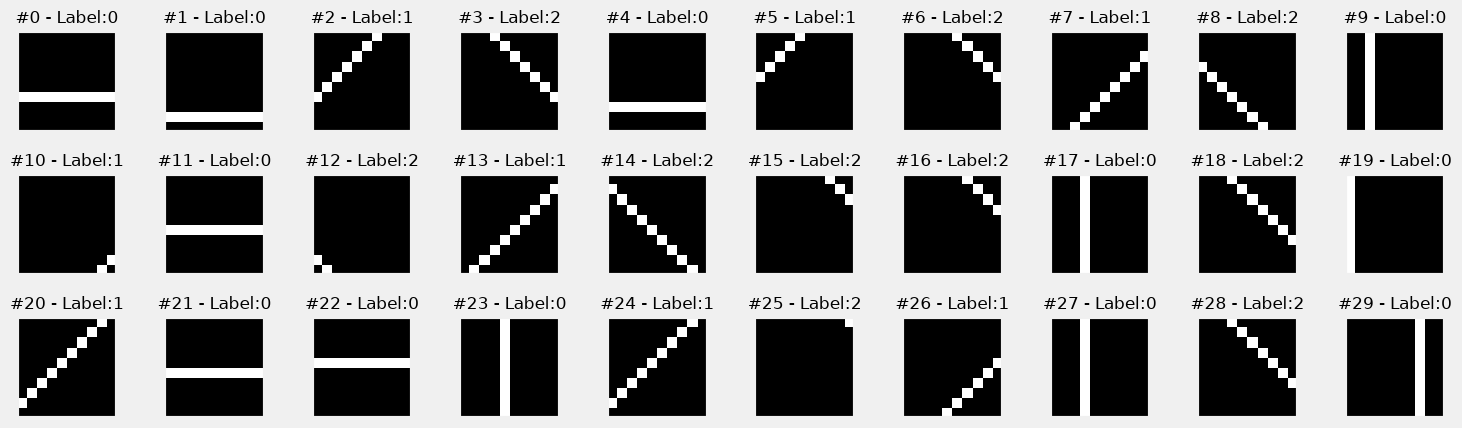

In [18]:
# 数据生成

images,labels = generate_dataset(img_size=10,n_images=1000
                                 ,binary=False
                                 ,seed=17)


fig = plot_images(images,labels,n_plot=30)

## 数据准备


结合代码:

**Q**: 数据准备修改了什么？

**Q**: 为什么不执行数据增强？

In [19]:
#程序5-13: 图像DataSet

class TransformedTensorDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform
        
    def __getitem__(self, index):
        x = self.x[index]
        
        if self.transform:
            x = self.transform(x)
        
        return x, self.y[index]
        
    def __len__(self):
        return len(self.x)

In [20]:
#程序5-14: 数据准备

# 图像处理: [0,255]->[0,1]
x_tensor = torch.as_tensor(images/255).float()
y_tensor = torch.as_tensor(labels).long()

# 自定函数:index_splitter
# 拆分数据集索引
train_idx,val_idx = index_splitter(len(x_tensor),[80,20])

#使用索引拆分(要处理不平衡数据)
x_train_tensor = x_tensor[train_idx]
y_train_tensor = y_tensor[train_idx]
x_val_tensor = x_tensor[val_idx]
y_val_tensor = y_tensor[val_idx]

# 标准化但不做数据增强
train_composer = Compose([Normalize(mean=(.5,),std=(.5,))])
val_composer = Compose([Normalize(mean=(.5,),std=(.5,))])

# 使用自定义数据集存储图像
train_dataset = TransformedTensorDataset(x_train_tensor,y_train_tensor
                                         ,transform=train_composer)
val_dataset = TransformedTensorDataset(x_val_tensor,y_val_tensor
                                         ,transform=train_composer)

# 随机采样处理不平衡类
sampler = make_balanced_sampler(y_train_tensor)

# 在训练集中采用采样器获得平衡数据
train_loader = DataLoader(dataset=train_dataset,batch_size=16,sampler=sampler)
val_loader = DataLoader(dataset=val_dataset,batch_size=16)


## 损失函数

**Q**: 在接入损失函数之前，输出层的输出可能有哪两种数据类型？

**Q**: 复习: logit,比值比,对数比值比

**Q**: Sigmoid为什么不能胜任处理多分类问题？

---

**Q**：SoftMax 返回的是什么？输入是什么？

**Q**: SoftMax 公式是什么？

结合代码:

**Q**: SoftMax有几种实现形式？

**Q**: `dim=-1`是什么意思？

---

**Q**: LogSoftMax是什么？有什么意义？

**Q**: 负对数似然损失函数是什么？和二元交叉熵函数的区别？

结合代码:

**Q**: LogSoftMax有几种实现形式？

**Q**: NLL损失函数的函数版是如何使用的？有什么注意点？

**Q**: NLL损失函数的模板版如何使用？几个参数的意义？(尤其是weight的意义和`BCEWithLogitsLoss`有什么不同？)

---

**Q**: `BCEWithLogitsLoss`和`CrossEntropyLoss`有什么异同？

**Q**: SoftMax是否为最后一层对损失函数类的选择有什么影响？

结合代码:


**Q**: CrossEntropyLoss有几种实现形式？

In [21]:
# 手动计算SoftMax

# 输入logit(对数比值比)
logits = torch.tensor([ 1.3863,  0.0000, -0.6931])

# softmax需要比值比
odds_ratios = torch.exp(logits)
print(odds_ratios)

# 计算softmax
softmaxed = odds_ratios / odds_ratios.sum()

print(softmaxed)

tensor([4.0000, 1.0000, 0.5000])
tensor([0.7273, 0.1818, 0.0909])


In [22]:
#程序5-15: pytorch中SoftMax的使用

print(nn.Softmax(dim=-1)(logits))

print(F.softmax(logits, dim=-1))

tensor([0.7273, 0.1818, 0.0909])
tensor([0.7273, 0.1818, 0.0909])


In [23]:
#程序5-15: pytorch中LogSoftMax和NLL损失函数的使用

# LogSoftMax
log_probs = F.log_softmax(logits, dim=-1)
print(log_probs.shape,log_probs.view(-1, 3).shape)
print(nn.LogSoftmax(dim=-1)(logits))

# NLL损失函数

# 损失针对的是真实标签进行计算的
label = torch.tensor([2])
print(F.nll_loss(log_probs.view(-1, 3), label))


torch.Size([3]) torch.Size([1, 3])
tensor([-0.3185, -1.7048, -2.3979])
tensor(2.3979)


In [24]:
#程序5-16: pytorch中NNL损失函数的使用

# 构造数据
torch.manual_seed(11)
## logits
dummy_logits = torch.randn((5, 3))
## labels
dummy_labels = torch.tensor([0, 0, 1, 2, 1])
## 概率
dummy_log_probs = F.log_softmax(dummy_logits, dim=-1)
print(dummy_log_probs)

# 实际标签对应的logit
relevant_log_probs = torch.tensor([-1.5229, -1.7934, -1.0136, -2.0367, -1.9098])
# 手动计算mean损失
print(-relevant_log_probs.mean())

# NLL损失计算
loss_fn = nn.NLLLoss()
print(loss_fn(dummy_log_probs, dummy_labels))

tensor([[-1.5229, -0.3146, -2.9600],
        [-1.7934, -1.0044, -0.7607],
        [-1.2513, -1.0136, -1.0471],
        [-2.6799, -0.2219, -2.0367],
        [-1.0728, -1.9098, -0.6737]])
tensor(1.6553)
tensor(1.6553)


In [25]:
#程序5-17: 不平衡数据集下pytorch中NNL损失函数的使用

loss_fn = nn.NLLLoss(weight=torch.tensor([1., 1., 2.]))
print(loss_fn(dummy_log_probs, dummy_labels))

tensor(1.7188)


In [26]:
#程序5-18: 排除某标签情况下pytorch中NNL损失函数的使用

loss_fn = nn.NLLLoss(ignore_index=2)
print(loss_fn(dummy_log_probs, dummy_labels))

tensor(1.5599)


In [27]:
#程序5-19: 交叉熵函数的使用

torch.manual_seed(11)
dummy_logits = torch.randn((5, 3))
dummy_labels = torch.tensor([0, 0, 1, 2, 1])

loss_fn = nn.CrossEntropyLoss()
loss_fn(dummy_logits, dummy_labels)

tensor(1.6553)

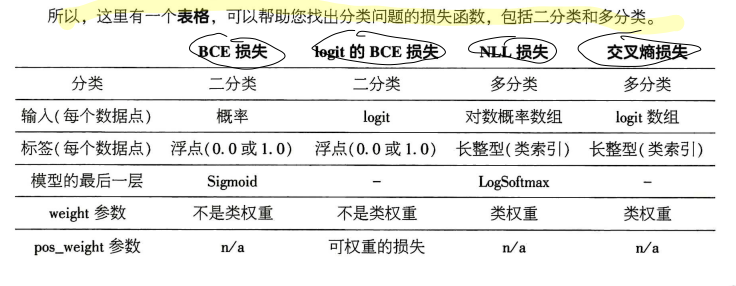

## 模型配置

![](../images/classification_softmax.png)

结合代码：

**Q**: 模型配置添加了什么?

In [28]:
#程序5-20: 模型配置（特征化）

torch.manual_seed(13)
model_cnn1 = nn.Sequential()

# 特征化图像

# 卷积块:Block 1: 1@10x10 -> n_channels@8x8 -> n_channels@4x4
n_channels = 1
model_cnn1.add_module('conv1', nn.Conv2d(in_channels=1, out_channels=n_channels, kernel_size=3))
model_cnn1.add_module('relu1', nn.ReLU())
model_cnn1.add_module('maxp1', nn.MaxPool2d(kernel_size=2))
# 展平:Flattening: n_channels * 4 * 4
model_cnn1.add_module('flatten', nn.Flatten())

In [29]:
#程序5-21: 模型配置(分类)

# 隐藏层
model_cnn1.add_module('fc1', nn.Linear(in_features=n_channels*4*4, out_features=10))
model_cnn1.add_module('relu2', nn.ReLU())
# 输出层
model_cnn1.add_module('fc2', nn.Linear(in_features=10, out_features=3))
model_cnn1

Sequential(
  (conv1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (maxp1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=16, out_features=10, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)

In [30]:
#程序5-22: 模型配置(损失和优化器)

lr =0.1
lr = 0.1
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn1 = optim.SGD(model_cnn1.parameters(), lr=lr)

## 模型训练

结合代码：

**Q**: 复习:StepByStep类

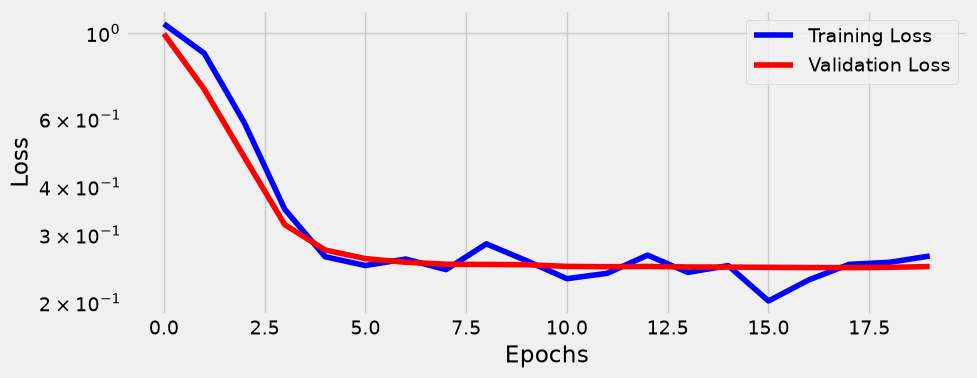

In [31]:
#程序5-23: 模型训练


sbs_cnn1 = StepByStep(model_cnn1, multi_loss_fn, optimizer_cnn1)
sbs_cnn1.set_loaders(train_loader, val_loader)

sbs_cnn1.train(20)

# 可视化结果
fig = sbs_cnn1.plot_losses()

# 然后，我要干什么？

关于训练的部分已经完成，剩下的就是可视化：
- 可视化滤波器
- 可视化特征图
- 可视化分类器层

首先弄清如何可视化，还得想办法将可视化的方法融入训练类中，在前向传播时自动捕捉，这就引出了**钩子hook**这一概念

最后再计算准确率来对模型进行评价

# 可视化

## Python: 静态方法

**Q**: 静态方法是什么？

**Q**: 装饰器是什么？

In [32]:
#程序5-24: 静态方法和装饰器使用

class Cat(object):
    def __init__(self, name):
        self.name = name

    @staticmethod
    def meow():
        print('Meow')

Cat.meow()

Meow


## 可视化张量

In [33]:
# 可视化张量方法

@staticmethod
def _visualize_tensors(axs, x, y=None, yhat=None, 
                       layer_name='', title=None):
    # 子图的数量
    n_images = len(axs)
    # 获取缩放灰度的最值
    minv, maxv = np.min(x[:n_images]), np.max(x[:n_images])
    # 处理每张图片
    for j, image in enumerate(x[:n_images]):
        ax = axs[j]
        # 设置标题,标签,删除刻度
        if title is not None:
            ax.set_title(f'{title} #{j}', fontsize=12)
        shp = np.atleast_2d(image).shape
        ax.set_ylabel(
            f'{layer_name}\n{shp[0]}x{shp[1]}',
            rotation=0, labelpad=40
        )
        xlabel1 = '' if y is None else f'\nLabel: {y[j]}'
        xlabel2 = '' if yhat is None else f'\nPredicted: {yhat[j]}'
        xlabel = f'{xlabel1}{xlabel2}'
        if len(xlabel):
            ax.set_xlabel(xlabel, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

        # 权重绘制为图像
        ax.imshow(
            np.atleast_2d(image.squeeze()),
            cmap='gray', 
            vmin=minv, 
            vmax=maxv
        )
    return

setattr(StepByStep, '_visualize_tensors', _visualize_tensors)

## 可视化滤波器

结合代码:

**Q**: 如何使用可视化滤波器？

In [34]:
# 可视化滤波器

def visualize_filters(self, layer_name, **kwargs):
    try:
        # 获取模型层
        layer = self.model
        for name in layer_name.split('.'):
            layer = getattr(layer, name)
        # 只关注2D卷积的滤波器
        if isinstance(layer, nn.Conv2d):
            # 获取权重
            weights = layer.weight.data.cpu().numpy()
            # weights -> (输出通道 (filter), 输入通道, H, W)
            n_filters, n_channels, _, _ = weights.shape

            # Builds a figure
            size = (2 * n_channels + 2, 2 * n_filters)
            fig, axes = plt.subplots(n_filters, n_channels, 
                                     figsize=size)
            axes = np.atleast_2d(axes)
            axes = axes.reshape(n_filters, n_channels)
            # For each channel_out (filter)
            for i in range(n_filters):    
                StepByStep._visualize_tensors(
                    axes[i, :],
                    weights[i],
                    layer_name=f'Filter #{i}', 
                    title='Channel'
                )
                    
            for ax in axes.flat:
                ax.label_outer()

            fig.tight_layout()
            return fig
    except AttributeError:
        return
    
setattr(StepByStep, 'visualize_filters', visualize_filters)

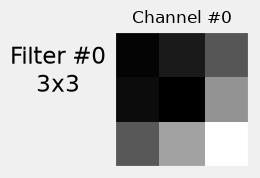

In [35]:
fig = sbs_cnn1.visualize_filters('conv1', cmap='gray')

## 钩子

**Q**: 钩子是什么功能？

结合代码：

**Q**: 前向钩子需要哪些参数？

**Q**: `named_modules`的作用是什么?

In [36]:
#程序5-25: 前向钩子的使用方法

# 构造模型
dummy_model = nn.Linear(1, 1)

# 钩子: 单纯放入list
dummy_list = []
def dummy_hook(layer, inputs, outputs):
    dummy_list.append((layer, inputs, outputs))

# 注册前向钩子,获得句柄
dummy_handle = dummy_model.register_forward_hook(dummy_hook)
print(dummy_handle)

# 注: 调用方法无法触发
dummy_x = torch.tensor([0.3])
dummy_model.forward(dummy_x)
print(dummy_list.__len__())

# 必须用类名触发
dummy_model(dummy_x)
print(dummy_list)

# 删除钩子
dummy_handle.remove()




0
[(Linear(in_features=1, out_features=1, bias=True), (tensor([0.3000]),), tensor([-0.8366], grad_fn=<ViewBackward0>))]


In [37]:
#程序5-26: named_modules的使用

modules = list(sbs_cnn1.model.named_modules())

# 注:第一个元素是模型本身,接下来则是各层名字字典
print(modules)
print()
layer_names = {layer: name for name, layer in modules[1:]}
print(layer_names)

[('', Sequential(
  (conv1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (maxp1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=16, out_features=10, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)), ('conv1', Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))), ('relu1', ReLU()), ('maxp1', MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)), ('flatten', Flatten(start_dim=1, end_dim=-1)), ('fc1', Linear(in_features=16, out_features=10, bias=True)), ('relu2', ReLU()), ('fc2', Linear(in_features=10, out_features=3, bias=True))]

{Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1)): 'conv1', ReLU(): 'relu1', MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False): 'maxp1', Flatten(start_dim=1, end_dim=-1): 'flatten', Linear(in_features=16, out_features=10, bias=True): 'fc1', ReLU(): 'relu

## 可视化操作

结合代码:

**Q**: 为什么最终要清楚句柄？

In [38]:
#程序5-27: 预测并存储数据

# 存储可视化数据
visualization = {}

# 钩子函数
def hook_fn(layer, inputs, outputs):
    name = layer_names[layer]
    visualization[name] = outputs.detach().cpu().numpy()



# 存储句柄
handles = {}

# 为曾对象注册钩子
layers_to_hook = ['conv1', 'relu1', 'maxp1', 'flatten', 'fc1', 'relu2', 'fc2']
for name, layer in modules:
    if name in layers_to_hook:
        handles[name] = layer.register_forward_hook(hook_fn)


# 预测
images_batch, labels_batch = next(iter(val_loader))
logits = sbs_cnn1.predict(images_batch)

# 检查结果
print(visualization.keys())

# 清楚钩子
for handle in handles.values():
    handle.remove()
handles = {}

dict_keys(['conv1', 'relu1', 'maxp1', 'flatten', 'fc1', 'relu2', 'fc2'])


In [39]:
#程序5-28: 将钩子逻辑整理入类中
setattr(StepByStep, 'visualization', {})
setattr(StepByStep, 'handles', {})

def attach_hooks(self, layers_to_hook, hook_fn=None):
    # 清楚过往值
    self.visualization = {}
    # 创建字典映射名字
    modules = list(self.model.named_modules())
    layer_names = {layer: name for name, layer in modules[1:]}

    if hook_fn is None:
        # 建立钩子函数
        def hook_fn(layer, inputs, outputs):
            # 获得层名称
            name = layer_names[layer]
            # 分离输出
            values = outputs.detach().cpu().numpy()
            # 处理连接结果（因为钩子函数可能调用多次）
            if self.visualization[name] is None:
                self.visualization[name] = values
            else:
                self.visualization[name] = np.concatenate([self.visualization[name], values])

    for name, layer in modules:
        # 如果层在列表中
        if name in layers_to_hook:
            # 初始化字典对应内容
            self.visualization[name] = None
            # 注册函数
            self.handles[name] = layer.register_forward_hook(hook_fn)

def remove_hooks(self):
    # Loops through all hooks and removes them
    for handle in self.handles.values():
        handle.remove()
    # Clear the dict, as all hooks have been removed
    self.handles = {}
    
setattr(StepByStep, 'attach_hooks', attach_hooks)
setattr(StepByStep, 'remove_hooks', remove_hooks)

In [40]:
# 测试函数

sbs_cnn1.attach_hooks(layers_to_hook=['conv1', 'relu1', 'maxp1', 'flatten', 'fc1', 'relu2', 'fc2'])

images_batch, labels_batch = next(iter(val_loader))
logits = sbs_cnn1.predict(images_batch)

sbs_cnn1.remove_hooks()

# 最大的logit的索引就是类别
predicted = np.argmax(logits, 1)
print(logits)
print(predicted)

[[ -0.4887944   -0.7404922    1.4700942 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [  8.7027025    1.7882531   -5.4677606 ]
 [  6.4708967   -1.2642074   -2.8014874 ]
 [  8.7027025    1.7882531   -5.4677606 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [  0.86324096   6.231266    -5.2358427 ]
 [ 10.006319     2.7432714  -10.843268  ]
 [ -0.85741925   5.0247865   -2.7073317 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [  1.2477831    7.582758    -5.8709097 ]
 [ -0.4887944   -0.7404922    1.4700942 ]
 [  7.3204007   -0.02116424  -2.1209354 ]]
[2 2 2 0 0 0 2 2 2 1 0 1 2 1 2 0]


## 可视化特征图

In [41]:
# 可视化特征图函数

def visualize_outputs(self, layers, n_images=10, y=None, yhat=None):
    layers = filter(lambda l: l in self.visualization.keys(), layers)
    layers = list(layers)
    shapes = [self.visualization[layer].shape for layer in layers]
    n_rows = [shape[1] if len(shape) == 4 else 1 
              for shape in shapes]
    total_rows = np.sum(n_rows)

    fig, axes = plt.subplots(total_rows, n_images, 
                             figsize=(1.5*n_images, 1.5*total_rows))
    axes = np.atleast_2d(axes).reshape(total_rows, n_images)
    
    # Loops through the layers, one layer per row of subplots
    row = 0
    for i, layer in enumerate(layers):
        start_row = row
        # Takes the produced feature maps for that layer
        output = self.visualization[layer]
            
        is_vector = len(output.shape) == 2
        
        for j in range(n_rows[i]):
            StepByStep._visualize_tensors(
                axes[row, :],
                output if is_vector else output[:, j].squeeze(),
                y, 
                yhat, 
                layer_name=layers[i] \
                           if is_vector \
                           else f'{layers[i]}\nfil#{row-start_row}',
                title='Image' if (row == 0) else None
            )
            row += 1
            
    for ax in axes.flat:
        ax.label_outer()

    plt.tight_layout()
    return fig

setattr(StepByStep, 'visualize_outputs', visualize_outputs)

In [44]:
plt.style.available

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

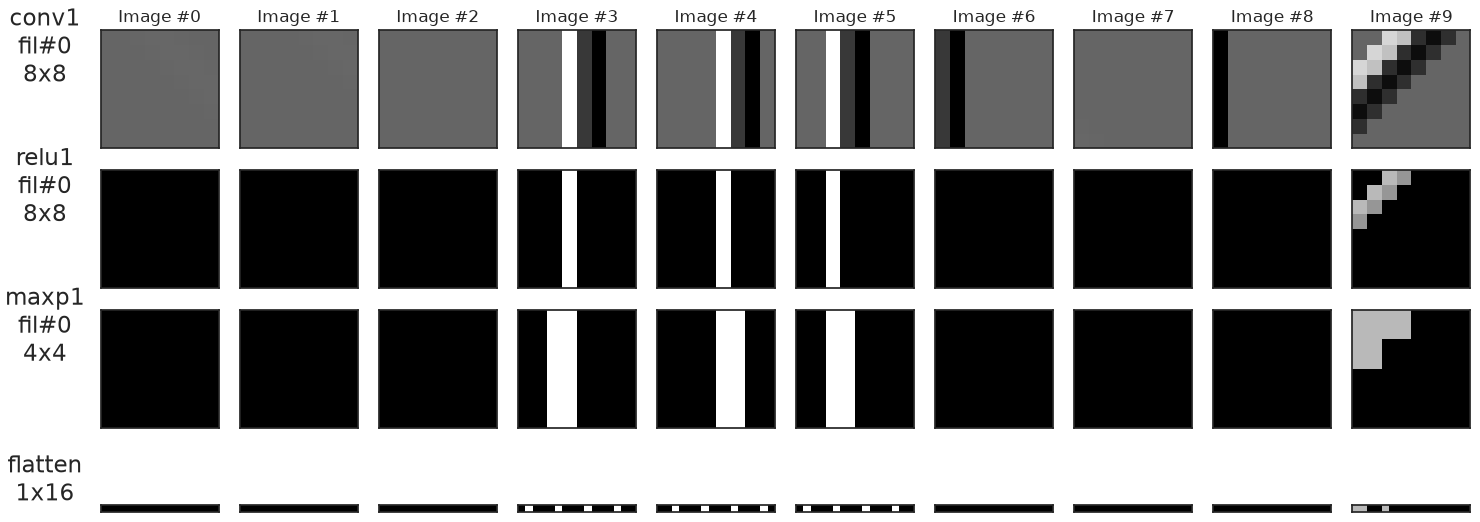

In [45]:
featurizer_layers = ['conv1', 'relu1', 'maxp1', 'flatten']

with plt.style.context('seaborn-v0_8-white'):
    fig = sbs_cnn1.visualize_outputs(featurizer_layers)

## 可视化分类器层

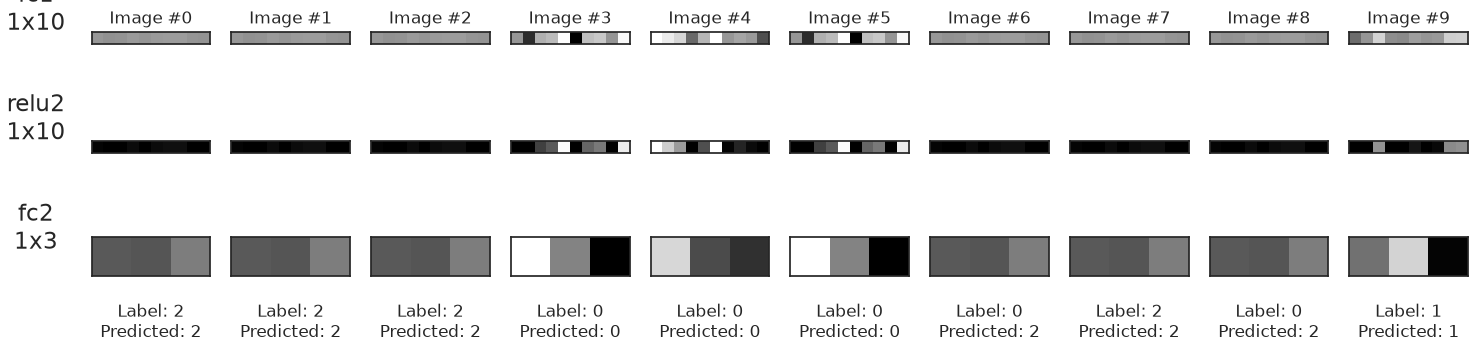

In [47]:
classifier_layers = ['fc1', 'relu2', 'fc2']

with plt.style.context('seaborn-v0_8-white'):
    fig = sbs_cnn1.visualize_outputs(classifier_layers, y=labels_batch, yhat=predicted)

# 准确率

In [48]:
# 计算准确率
def correct(self, x, y, threshold=.5):
    self.model.eval()
    yhat = self.model(x.to(self.device))
    y = y.to(self.device)
    self.model.train()
    
    # 获取batch的大小和类别数量
    # （如果是二分类，则只有1）
    n_samples, n_dims = yhat.shape
    if n_dims > 1:        
        # 在多分类中，最大的logit总是胜出，
        # 所以我们不需要费心去获取概率
        
        # 这是PyTorch版本的argmax，
        # 但它返回一个元组：(最大值, 最大值的索引)
        _, predicted = torch.max(yhat, 1)
    else:
        n_dims += 1
        # 在二分类中，我们需要检查
        # 最后一层是否是sigmoid（它会输出概率）
        if isinstance(self.model, nn.Sequential) and \
           isinstance(self.model[-1], nn.Sigmoid):
            predicted = (yhat > threshold).long()
        # 或者最后一层输出的是logits，
        # 我们需要用sigmoid来转换
        else:
            predicted = (F.sigmoid(yhat) > threshold).long()
    
    # 统计每个类别有多少样本被正确分类
    result = []
    for c in range(n_dims):
        n_class = (y == c).sum().item()
        n_correct = (predicted[y == c] == c).sum().item()
        result.append((n_correct, n_class))
    return torch.tensor(result)

setattr(StepByStep, 'correct', correct)

In [49]:
sbs_cnn1.correct(images_batch, labels_batch)

tensor([[5, 7],
        [3, 3],
        [6, 6]])

## Loader Apply

In [50]:
# 对每个批次调用func函数，最后通过reduce累加

@staticmethod
def loader_apply(loader, func, reduce='sum'):
    results = [func(x, y) for i, (x, y) in enumerate(loader)]
    results = torch.stack(results, axis=0)

    if reduce == 'sum':
        results = results.sum(axis=0)
    elif reduce == 'mean':
        results = results.float().mean(axis=0)
    
    return results

setattr(StepByStep, 'loader_apply', loader_apply)

In [51]:
StepByStep.loader_apply(sbs_cnn1.val_loader, sbs_cnn1.correct)

tensor([[59, 67],
        [55, 62],
        [71, 71]])